In [10]:
import pandas as pd
pumpkins = pd.read_csv('../data/US-pumpkins.csv')
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [11]:
# pumpkins.isnull().sum()
columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

In [12]:
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2
month = pd.DatetimeIndex(pumpkins['Date']).month

new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Price': price})
new_pumpkins.head(20)

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,15.00
71,9,1 1/9 bushel cartons,18.0,18.0,18.00
72,10,1 1/9 bushel cartons,18.0,18.0,18.00
73,10,1 1/9 bushel cartons,17.0,17.0,17.00
74,10,1 1/9 bushel cartons,15.0,15.0,15.00
75,10,1 1/9 bushel cartons,18.0,18.0,18.00
76,10,1 1/9 bushel cartons,17.0,17.0,17.00
77,10,1 1/9 bushel cartons,17.0,18.5,17.75
78,10,1 1/9 bushel cartons,15.0,15.0,15.00
79,10,1 1/9 bushel cartons,17.0,17.0,17.00


In [13]:
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

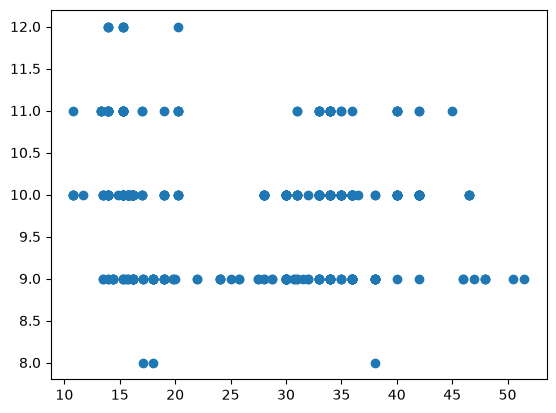

In [14]:
import matplotlib.pyplot as plt

# Get the values we want to plot
price = new_pumpkins.Price
month = new_pumpkins.Month

# Create the scatter plot
plt.scatter(price, month)
plt.show()

Text(0, 0.5, 'Pumpkin Price')

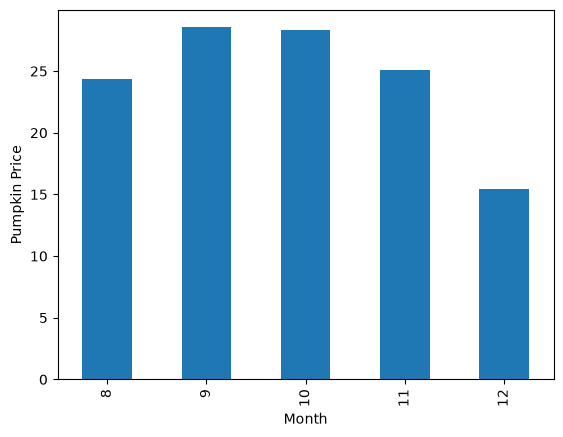

In [15]:
# Group the pumpkins into a bar chart
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')

# Add a label to the bar chart
plt.ylabel('Pumpkin Price')